<a href="https://colab.research.google.com/github/andysanchez1403-droid/ANDREA-GLZ-SNZ/blob/main/TAREA_2_PRUEBA_DE_FRECUENCIAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Extraemos el url de Github donde está ubiccado el excel
url = 'https://github.com/andysanchez1403-droid/ANDREA-GLZ-SNZ/raw/main/DATOS.xlsx'

# Leemos el archivo de Excel
# Nota: Si marca error de openpyxl, corre primero: !pip install openpyxl
df = pd.read_excel(url, engine='openpyxl')

# Extraer y aplanar los datos
datos_todos = df.values.flatten()

# Cálculos de promedio
N = len(datos_todos)
promedio = sum(datos_todos) / N

# Resultados
print(f"Archivo cargado desde: {url}")
print(f"Total de datos (N): {N}")
print(f"Promedio final (x̄): {promedio:.5f}")

Archivo cargado desde: https://github.com/andysanchez1403-droid/ANDREA-GLZ-SNZ/raw/main/DATOS.xlsx
Total de datos (N): 100
Promedio final (x̄): 0.48234


#**PRUEBA DE FRECUENCIAS**

Con lo anterior la **PRUEBA DE PROMEDIOS** solo nos ayudo a revisar si los datos se encontraban en el centro de 0.5 mientras que ahora la **PRUEBA DE FRECUENCIAS** nos ayudará a ver si los datos están bien repartidos en el intervalo de [0,1].

Calculamos **los grados de libertad (gl)** los cuales nos van a ayudar a representar el número de trozos, con ayuda del número de intervalo el cuál serán 5, entonces:

In [2]:
# Definimos el número de intervalos:
n = 5

#Aplicamos la fórmula de GRADOS DE LIBERTAD:
gl= n-1

#Tenemos el resultado de grados de libertad:
print(f"Grados de libertad: {gl}")

Grados de libertad: 4


Ahora sí, la fórmula de **PRUEBA DE FRECUENCIAS** nos dice lo siguiente:

$$X_{0}^2= \sum_{i=1}^{n} \frac {(FO- FE)^2} {(FO)} $$

donde:

FO: Frecuencia Observada.

FE: Frecuencia Esperada.

In [3]:
import numpy as np
import scipy.stats as st
data = df.values.flatten()

#**a) FRECUENCIA OBSERVADA**

In [4]:
import numpy as np

# Definimos los rangos (bins) de 0 a 1
# [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
rangos = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# La función histogram cuenta cuántos datos están en cada rango
frecuencia_observada, bordes = np.histogram(data, bins=rangos)

for i in range(len(frecuencia_observada)):
    print(f"Rango {bordes[i]:.1f} - {bordes[i+1]:.1f}: {frecuencia_observada[i]} valores")

Rango 0.0 - 0.2: 21 valores
Rango 0.2 - 0.4: 22 valores
Rango 0.4 - 0.6: 19 valores
Rango 0.6 - 0.8: 23 valores
Rango 0.8 - 1.0: 15 valores


In [5]:
import numpy as np

# Definimos los límites de los rangos.
limites = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# 2. Obtenemos las frecuencias observadas.
# data son tus 100 números del Excel
fo_counts, _ = np.histogram(data, bins=limites)

# Acomodamos cada Rango como Fo_1, Fo_2, Fo_3, Fo_4, Fo_5
Fo_1 = fo_counts[0]
Fo_2 = fo_counts[1]
Fo_3 = fo_counts[2]
Fo_4 = fo_counts[3]
Fo_5 = fo_counts[4]

# Mostramos los resultados por rango.
print(f"Rango [0.0, 0.2] = Fo_1 = {Fo_1}")
print(f"Rango [0.2, 0.4] = Fo_2 = {Fo_2}")
print(f"Rango [0.4, 0.6] = Fo_3 = {Fo_3}")
print(f"Rango [0.6, 0.8] = Fo_4 = {Fo_4}")
print(f"Rango [0.8, 1.0] = Fo_5 = {Fo_5}")

Rango [0.0, 0.2] = Fo_1 = 21
Rango [0.2, 0.4] = Fo_2 = 22
Rango [0.4, 0.6] = Fo_3 = 19
Rango [0.6, 0.8] = Fo_4 = 23
Rango [0.8, 1.0] = Fo_5 = 15


#**b) FRECUENCIA ESPERADA**

In [6]:
import numpy as np
import pandas as pd

n_intervalos = 5
N = len(data)
# Calculamos la Frecuencia Esperada (FE)
# FE = Total de datos / número de intervalos
frecuencia_esperada = N / n_intervalos

print(f"Frecuencia esperada: {frecuencia_esperada}")

Frecuencia esperada: 20.0


In [7]:
# Frecuencia Esperada (FE) es 20 para 100 datos en 5 rangos
FE= 20
print(f"{FE}")

20


#**c) HACEMOS FO - FE**

In [8]:
#Restamos las frecuencias, frecuencia observada - frecuencia esperada
 #Cada uno de los rangos obtenidos con anterioridad con la frecuencia esperada.

Término_1 = Fo_1 - FE
print(f" Término 1 = {Término_1}")

Término_2 = Fo_2 - FE
print(f" Término 2 = {Término_2}")

Término_3 = Fo_3 - FE
print(f" Término 3 = {Término_3}")

Término_4 = Fo_4 - FE
print(f" Término 4 = {Término_4}")

Término_5 = Fo_5 - FE
print(f" Término 5 = {Término_5}")

 Término 1 = 1
 Término 2 = 2
 Término 3 = -1
 Término 4 = 3
 Término 5 = -5


De acuerdo a la fórmula ahora los resultados obtenidos los elevamos al cuadrado, entonces nos queda de la siguiente manera:

In [9]:
# De acuerdo a la fórmula de (FO-FE)**2, vamos realizando cada término:

T1 = (Término_1)**2
print(f"T1 = {T1}")

T2 = (Término_2)**2
print(f"T2 = {T2}")

T3 = (Término_3)**2
print(f"T3 = {T3}")

T4 = (Término_4)**2
print(f"T4 = {T4}")

T5 = (Término_5)**2
print(f"T5 = {T5}")

T1 = 1
T2 = 4
T3 = 1
T4 = 9
T5 = 25


Realizamos la división de cada uno de los resultados obtenidos entre **Frecuencia Observada** igualmente de cada uno y respectivamente, entonces:

In [10]:
#Tn/FO_n
#Rn= Resultado de cada división.

R1= T1/Fo_1
print(f"R1 = {T1/Fo_1 }")

R2= T2/Fo_2
print(f"R2 = {T2/Fo_2 }")

R3= T3/Fo_3
print(f"R3 = {T3/Fo_3 }")

R4= T4/Fo_4
print(f"R4 = {T4/Fo_4 }")

R5= T5/Fo_5
print(f"R5 = {T5/Fo_5 }")

R1 = 0.047619047619047616
R2 = 0.18181818181818182
R3 = 0.05263157894736842
R4 = 0.391304347826087
R5 = 1.6666666666666667


Finalmente realizamos la suma de Chi Cuadrada ($\chi^2$):

In [11]:
#Sumamos todos los resultados obtenidos con anterioridad:

 #X_total= R1 + R2 + R3 + R4 + R5

X_total= R1 + R2 + R3 + R4 + R5
print(f"X_total= {R1 + R2 + R3 + R4 + R5}" )

X_total= 2.3400398228773516


In [12]:
import pandas as pd

# Asignamos el nombre para cada columna correspondiente.
intervalos_nombres = ["[0.0, 0.2]", "[0.2, 0.4]", "[0.4, 0.6]", "[0.6, 0.8]", "[0.8, 1.0]"]
fo = [Fo_1, Fo_2, Fo_3, Fo_4, Fo_5]
N = sum(fo)
valor_fe = N / 5

# Colocamos los cálculos correspondientes
fe_columna = [valor_fe] * 5
resta_fo_fe = [f - valor_fe for f in fo]
resta_al_cuadrado = [(r)**2 for r in resta_fo_fe]

# Dividimos todo entre FRECUENCIA OBSERVADA respectivamente(Fo)
resultado_final = []
for i in range(len(fo)):
    if fo[i] != 0:
        resultado_final.append(resta_al_cuadrado[i] / fo[i])
    else:
        resultado_final.append(0) # Evitamos error si una casilla está vacía

# Creamos la tabla
tabla_datos = {
    'Intervalos': intervalos_nombres,
    'Fo': fo,
    'Fe': fe_columna,
    'Fo - Fe': resta_fo_fe,
    '(Fo - Fe)^2': resta_al_cuadrado,
    '(Fo - Fe)^2 / Fo': resultado_final  # Columna actualizada
}

df_final = pd.DataFrame(tabla_datos)

# --- 4. RESULTADO ---
print(df_final.to_string(index=False))

chi_total = sum(resultado_final)
print(f"\nChi total): {chi_total:.4f}")

Intervalos  Fo   Fe  Fo - Fe  (Fo - Fe)^2  (Fo - Fe)^2 / Fo
[0.0, 0.2]  21 20.0      1.0          1.0          0.047619
[0.2, 0.4]  22 20.0      2.0          4.0          0.181818
[0.4, 0.6]  19 20.0     -1.0          1.0          0.052632
[0.6, 0.8]  23 20.0      3.0          9.0          0.391304
[0.8, 1.0]  15 20.0     -5.0         25.0          1.666667

Chi total): 2.3400


In [13]:
X_total= 2.3400
chi_limite = 9.4877
#Buscando en la tabla teniendo 4 grados de libertad

if X_total < chi_limite:
    print(f"Como {X_total} < {chi_limite}, se ACEPTA la uniformidad de los datos.")
else:
    print(f"Como {X_total} >= {chi_limite}, se RECHAZA la uniformidad.")

Como 2.34 < 9.4877, se ACEPTA la uniformidad de los datos.


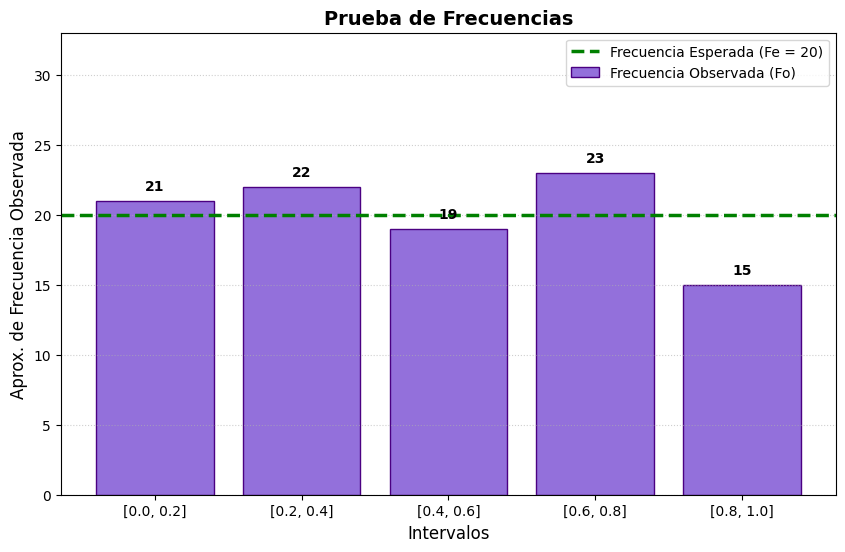

In [15]:
import matplotlib.pyplot as plt

# Verificamos los datos
intervalos = ["[0.0, 0.2]", "[0.2, 0.4]", "[0.4, 0.6]", "[0.6, 0.8]", "[0.8, 1.0]"]
fo = [Fo_1, Fo_2, Fo_3, Fo_4, Fo_5]
fe = 20 # FE

# Creamos la gráfica
plt.figure(figsize=(10, 6))

# Dibujamos la gráfica
barras = plt.bar(intervalos, fo, color='mediumpurple', edgecolor='indigo', label='Frecuencia Observada (Fo)')

# Dibujar la línea horizontal
plt.axhline(y=fe, color='green', linestyle='--', linewidth=2.5, label=f'Frecuencia Esperada (Fe = {fe})')

# Diseño Personalizado
plt.title('Prueba de Frecuencias', fontsize=14, fontweight='bold')
plt.xlabel('Intervalos', fontsize=12)
plt.ylabel('Aprox. de Frecuencia Observada', fontsize=12)
plt.ylim(0, max(fo) + 10)
plt.legend()

# Agregamos títulos
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle=':', alpha=0.6)

# Mostrar la gráfica
plt.show()